In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_style("whitegrid")

Imports

In [12]:
from google.colab import files
uploaded = files.upload()

Saving customer_support_tickets.csv to customer_support_tickets (1).csv


Data uploading

In [18]:
df = pd.read_csv("customer_support_tickets.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


Data loading

In [19]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


Data inspecting

In [21]:
# Removing customer name and email
df = df.drop(columns=["Customer Name", "Customer Email"], errors="ignore")

# Column names
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

# Timestamp fields
df["first_response_time"] = pd.to_datetime(df["first_response_time"], errors="coerce")
df["time_to_resolution"] = pd.to_datetime(df["time_to_resolution"], errors="coerce")

# Drop rows with missing satisfaction rating
df = df.dropna(subset=["customer_satisfaction_rating"])

Data cleaning

In [25]:
df["handling_time_hours"] = (df["time_to_resolution"] - df["first_response_time"]).dt.total_seconds() / 3600

# For excluding negative handling time
negative_count = (df["handling_time_hours"] < 0).sum()
print(f"Excluded {negative_count} rows with negative handling time")

df = df[df["handling_time_hours"] >= 0]

Excluded 1365 rows with negative handling time


Excluding negative handling time

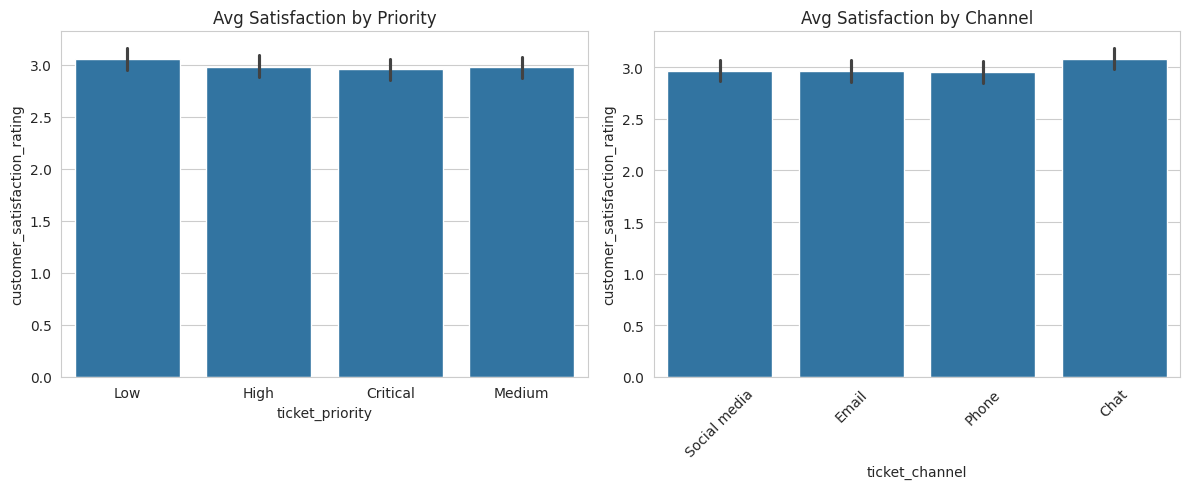

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x="ticket_priority", y="customer_satisfaction_rating", ax=axes[0])
axes[0].set_title("Avg Satisfaction by Priority")

sns.barplot(data=df, x="ticket_channel", y="customer_satisfaction_rating", ax=axes[1])
axes[1].set_title("Avg Satisfaction by Channel")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Satisfaction by priority and channel

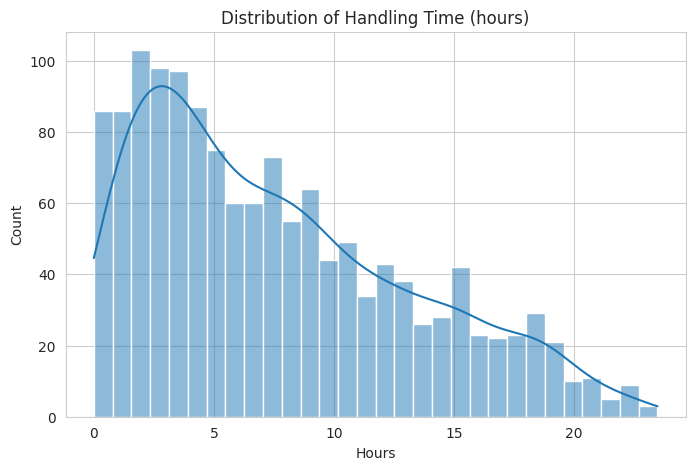

In [26]:
plt.figure(figsize=(8, 5))
sns.histplot(df["handling_time_hours"], bins=30, kde=True)
plt.title("Distribution of Handling Time (hours)")
plt.xlabel("Hours")
plt.show()

Handling time distribution

In [27]:
# Binary target: 1 = low satisfaction (rating <= 2), 0 = otherwise
df["low_satisfaction"] = (df["customer_satisfaction_rating"] <= 2).astype(int)
df["low_satisfaction"].value_counts(normalize=True)

/tmp/ipykernel_5068/3492049419.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["low_satisfaction"] = (df["customer_satisfaction_rating"] <= 2).astype(int)


,proportion
low_satisfaction,
0,0.614672
1,0.385328


Prediction target

In [28]:
features = ["ticket_priority", "ticket_channel", "ticket_type"]
X = df[features].copy()

encoders = {}
for col in features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

y = df["low_satisfaction"]

Categorical features

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Split and model testing

              precision    recall  f1-score   support

           0       0.62      0.61      0.62       173
           1       0.40      0.41      0.40       108

    accuracy                           0.53       281
   macro avg       0.51      0.51      0.51       281
weighted avg       0.54      0.53      0.53       281



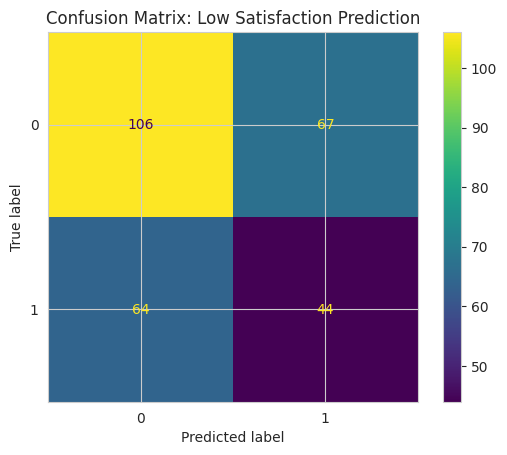

In [30]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix: Low Satisfaction Prediction")
plt.show()

Evaluation

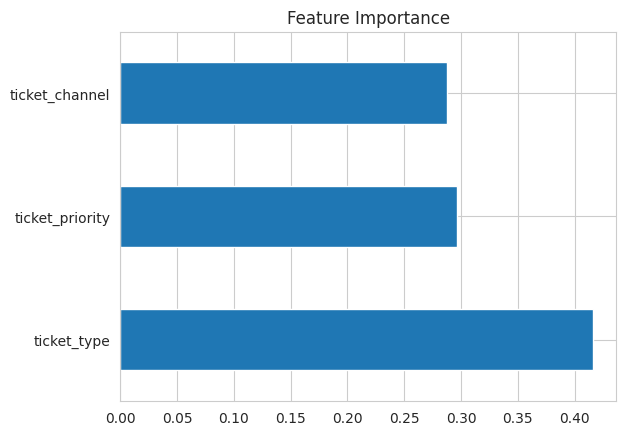

In [31]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importances.plot(kind="barh", title="Feature Importance")
plt.show()

Features and their importance

## Findings



*   Ticket type had the highest importance among the features.
*   Model accuracy is 0.53
*   Model precision is 0.54
*   Model recall is 0.53

 However, it is important to note that: Only 3 features were used, there is class imbalance in the target, and there is data quality issue with resolution timestamps where they result to negative handling time so these data were excluded.